<a href="https://colab.research.google.com/github/terry0809000/NLP-KCL/blob/main/representation/tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Term frequency x Inverse document frequency - TfIdf

With acknowledgement to Mayank Tripathi https://github.com/mayank408

TF calculation changed to that of Jurafsky and Martin, March 2026.

We will build on the BoW model creating a TfIdf model from first principles.

First a couple imports: "string" to do some string manipulation, pprint and pandas to help us print our data structures.

In [1]:
import string
import pprint as pp

import pandas as pd

import math

Now our corpus:

In [2]:
documents = ['Klonopin 0.25 mg po every evening, Fluconazole 200 mg po daily, Synthroid 125 mcg po every day',
             'she will not consider switching to clozapine',
             'lovastatin 40 mg one half tab po daily, multivitamin daily, metformin 500 mg one tab po twice a day',
             'Aspirin 81 mg po once daily, Zoloft 25 mg po once daily, Calcium with vitamin D two tablets po once daily']


We will "normalise" our documents, to lower case them and remove punctuation.

In [3]:
normalised_documents = []
for i in documents:
    no_punctuation = ''.join(c for c in i if c not in string.punctuation)
    normalised_documents.append(no_punctuation.lower())

for i in normalised_documents:
  print(i)

klonopin 025 mg po every evening fluconazole 200 mg po daily synthroid 125 mcg po every day
she will not consider switching to clozapine
lovastatin 40 mg one half tab po daily multivitamin daily metformin 500 mg one tab po twice a day
aspirin 81 mg po once daily zoloft 25 mg po once daily calcium with vitamin d two tablets po once daily


Let's split in to tokens, to give our "bags"

In [4]:
bows = []
for i in normalised_documents:
    bows.append(i.split(' '))

print(bows)

[['klonopin', '025', 'mg', 'po', 'every', 'evening', 'fluconazole', '200', 'mg', 'po', 'daily', 'synthroid', '125', 'mcg', 'po', 'every', 'day'], ['she', 'will', 'not', 'consider', 'switching', 'to', 'clozapine'], ['lovastatin', '40', 'mg', 'one', 'half', 'tab', 'po', 'daily', 'multivitamin', 'daily', 'metformin', '500', 'mg', 'one', 'tab', 'po', 'twice', 'a', 'day'], ['aspirin', '81', 'mg', 'po', 'once', 'daily', 'zoloft', '25', 'mg', 'po', 'once', 'daily', 'calcium', 'with', 'vitamin', 'd', 'two', 'tablets', 'po', 'once', 'daily']]


We need to get a set containing all of our unique words, so that we can calculate their relative
frequencies in each document and across all documents.

In [5]:
word_set = set()
for i in bows:
  word_set = word_set.union(set(i))
print(word_set)

{'200', 'zoloft', 'day', '40', 'daily', '125', 'twice', 'evening', 'mcg', 'po', 'she', 'aspirin', 'will', 'with', 'once', 'every', 'two', 'calcium', 'consider', 'lovastatin', 'clozapine', 'metformin', 'switching', '25', 'd', 'tablets', '81', 'half', 'klonopin', 'tab', 'one', 'vitamin', 'fluconazole', 'multivitamin', '025', 'not', 'mg', '500', 'synthroid', 'to', 'a'}


Let's count how many of each word we have for each of our bags:

In [6]:
wordCounts = []
for i in bows:
  thisWordCount = dict.fromkeys(word_set, 0)
  for word in i:
    thisWordCount[word]+=1
  wordCounts.append(thisWordCount)


Let's take a look at these counts:

In [7]:
pd.DataFrame(wordCounts)

,200,zoloft,day,40,daily,125,twice,evening,mcg,po,...,vitamin,fluconazole,multivitamin,025,not,mg,500,synthroid,to,a
0,1,0,1,0,1,1,0,1,1,3,...,0,1,0,1,0,2,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,1,1,2,0,1,0,0,2,...,0,0,1,0,0,2,1,0,0,1
3,0,1,0,0,3,0,0,0,0,3,...,1,0,0,0,0,2,0,0,0,0


Now we will define ***Term Frequency*** (TF) as how frequent of a word is in a bag (document). There are various alternative formulae, and TF is usually squashed by taking log base 10. We will define a function to compute this for all of the words in a bag, based on Jurafsky and Martin 3rd edition January 2026 draft, chapter 11.

In [8]:
def computeTF(wordCount, bow):
  tfDict = {}
  for word, count in wordCount.items():
    if count == 0:
      tfDict[word] = 0
    else:
      tfDict[word] = 1 + math.log10(count)
  return tfDict

We will run this function over all of our bags (documents), and put the resulting TFs in a single data structure. Tale a look and see how documents differ, and how the TFs reflect relative occurence of a word in each document.

In [9]:
termFreqs = []
for i in range(0,len(bows)):
  termFreqs.append(computeTF(wordCounts[i],bows[i]))

pd.DataFrame(termFreqs)

,200,zoloft,day,40,daily,125,twice,evening,mcg,po,...,vitamin,fluconazole,multivitamin,025,not,mg,500,synthroid,to,a
0,1.0,0.0,1.0,0.0,1.000000,1.0,0.0,1.0,1.0,1.477121,...,0.0,1.0,0.0,1.0,0.0,1.30103,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.00000,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,1.0,1.301030,0.0,1.0,0.0,0.0,1.301030,...,0.0,0.0,1.0,0.0,0.0,1.30103,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.477121,0.0,0.0,0.0,0.0,1.477121,...,1.0,0.0,0.0,0.0,0.0,1.30103,0.0,0.0,0.0,0.0


Our next function defines ***Inverse Docuemnt Frequency*** - IDF. This measures the rareness of a word across our whole collection of documents. For each word, we divide the total number of documents by the number containing that word. We take the log of this.

In [10]:
def computeIDF(docList):
    import math
    idfDict = {}
    N = len(docList)

    idfDict = dict.fromkeys(docList[0].keys(), 0)
    for doc in docList:
        for word, val in doc.items():
            if val > 0:
                idfDict[word] += 1

    for word, val in idfDict.items():
        idfDict[word] = math.log10(N / float(val))

    return idfDict

Now we compute IDF for our words. Take a look at the difference between common words like "mg" and rare ones like drug names.

In [11]:
idfs = computeIDF(wordCounts)
pp.pprint(idfs)

{'025': 0.6020599913279624,
 '125': 0.6020599913279624,
 '200': 0.6020599913279624,
 '25': 0.6020599913279624,
 '40': 0.6020599913279624,
 '500': 0.6020599913279624,
 '81': 0.6020599913279624,
 'a': 0.6020599913279624,
 'aspirin': 0.6020599913279624,
 'calcium': 0.6020599913279624,
 'clozapine': 0.6020599913279624,
 'consider': 0.6020599913279624,
 'd': 0.6020599913279624,
 'daily': 0.12493873660829992,
 'day': 0.3010299956639812,
 'evening': 0.6020599913279624,
 'every': 0.6020599913279624,
 'fluconazole': 0.6020599913279624,
 'half': 0.6020599913279624,
 'klonopin': 0.6020599913279624,
 'lovastatin': 0.6020599913279624,
 'mcg': 0.6020599913279624,
 'metformin': 0.6020599913279624,
 'mg': 0.12493873660829992,
 'multivitamin': 0.6020599913279624,
 'not': 0.6020599913279624,
 'once': 0.6020599913279624,
 'one': 0.6020599913279624,
 'po': 0.12493873660829992,
 'she': 0.6020599913279624,
 'switching': 0.6020599913279624,
 'synthroid': 0.6020599913279624,
 'tab': 0.6020599913279624,
 'tabl

What do the IDFs look like?

<Axes: >

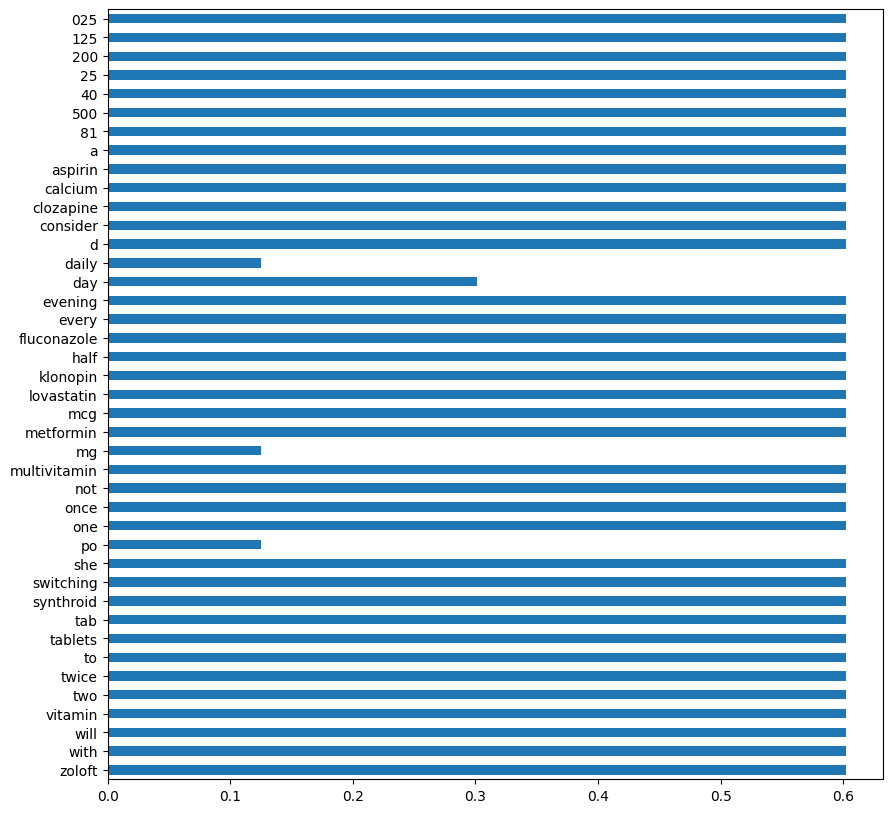

In [12]:
pd.Series(idfs).sort_index(ascending=False).plot.barh(figsize=(10,10))

Can you explain the range of values that IDF takes, and the maximum value? Below is a plot of log10(x) to help...

Text(0, 0.5, 'log(x)')

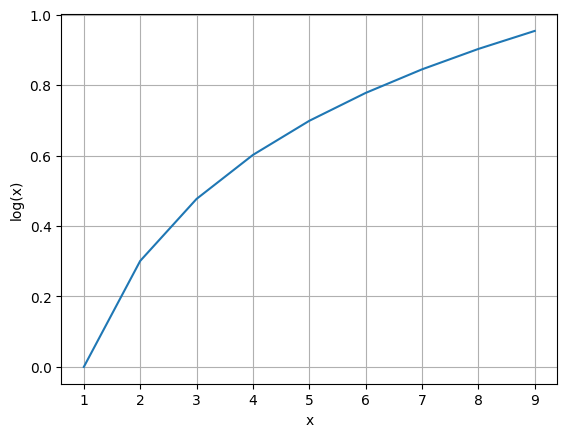

In [13]:
logs = pd.DataFrame([[i, math.log(i,10)] for i in range(1,10)], columns=["x", "log(x)"])
plot = logs.plot(x=0, y=1, kind='line', legend=False, grid=True)
plot.set_ylabel("log(x)")

Let's define a function to put TF and IDF together.

In [14]:
def computeTFIDF(tfBow, idfs):
    tfidf = {}
    for word, val in tfBow.items():
        tfidf[word] = val*idfs[word]
    return tfidf

And now run this over all of the documents in our term frequency list:

In [15]:
tfidfs = []
for i in termFreqs:
  tfidfs.append(computeTFIDF(i, idfs))



pd.DataFrame(tfidfs)


,200,zoloft,day,40,daily,125,twice,evening,mcg,po,...,vitamin,fluconazole,multivitamin,025,not,mg,500,synthroid,to,a
0,0.60206,0.00000,0.30103,0.00000,0.124939,0.60206,0.00000,0.60206,0.60206,0.184550,...,0.00000,0.60206,0.00000,0.60206,0.00000,0.162549,0.00000,0.60206,0.00000,0.00000
1,0.00000,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.60206,0.000000,0.00000,0.00000,0.60206,0.00000
2,0.00000,0.00000,0.30103,0.60206,0.162549,0.00000,0.60206,0.00000,0.00000,0.162549,...,0.00000,0.00000,0.60206,0.00000,0.00000,0.162549,0.60206,0.00000,0.00000,0.60206
3,0.00000,0.60206,0.00000,0.00000,0.184550,0.00000,0.00000,0.00000,0.00000,0.184550,...,0.60206,0.00000,0.00000,0.00000,0.00000,0.162549,0.00000,0.00000,0.00000,0.00000


How do these compare to the raw term counts? Run the next line to get just the term counts. What differences are there?

In [16]:
pd.DataFrame(wordCounts)

,200,zoloft,day,40,daily,125,twice,evening,mcg,po,...,vitamin,fluconazole,multivitamin,025,not,mg,500,synthroid,to,a
0,1,0,1,0,1,1,0,1,1,3,...,0,1,0,1,0,2,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,1,1,2,0,1,0,0,2,...,0,0,1,0,0,2,1,0,0,1
3,0,1,0,0,3,0,0,0,0,3,...,1,0,0,0,0,2,0,0,0,0
